# GAP Colab 技术路线说明

本 notebook 当前围绕以下技术路线组织：

1. 机械手 / 当前手部 mask 分割
2. 将精细 mask 转换为 lollipop mask
3. mask 掉当前手后，对空白区域进行 inpaint 背景修补
4. 使用 diffusion / FLUX Fill 生成符合语义的人手操作图像
5. 从 2D 人手操作图像恢复 3D MANO 手模型
6. 从 MANO / 指尖位置进一步转换为假肢动作

当前实现状态：

- `Step 1`：已实现，但当前 notebook 中为了验证流程，使用的是人手分割，不是最终机械手分割模型。
- `Step 2`：已实现，采用 Affordance Diffusion 风格的 lollipop proxy。
- `Step 3`：已实现，当前采用 ROI 级 inpainting。
- `Step 4`：已实现，当前使用 `FLUX.1-Fill-dev`。
- `Step 5`：已实现，当前使用 `HaMeR` 提取 MANO。
- `Step 6`：**尚未实现**。当前 notebook 还没有把 MANO / 指尖位置进一步映射成假肢控制命令。

建议按顺序运行，并将 `Step 6` 视作后续系统集成阶段的留白。


In [1]:
import os
if not os.path.exists("/content/Grounded-SAM-2"):
    !git clone https://github.com/IDEA-Research/Grounded-SAM-2.git
else:
    print("Grounded-SAM-2 repository already exists.")

Cloning into 'Grounded-SAM-2'...
remote: Enumerating objects: 2065, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 2065 (delta 11), reused 5 (delta 5), pack-reused 2046 (from 2)
Receiving objects: 100% (2065/2065), 230.08 MiB | 39.93 MiB/s, done.
Resolving deltas: 100% (769/769), done.


In [2]:
%cd /content/Grounded-SAM-2
!pip install -q -e ".[notebooks]"
!pip install -q --no-build-isolation -e grounding_dino
!pip install -q supervision addict yapf "transformers<=4.38.2"
# Install diffusers and its dependencies here to avoid import errors later
!pip install -q diffusers==0.27.2 "huggingface_hub<=0.25.2" "peft<=0.10.0"

import os
# Fix for Grounding DINO C++ extension not found
os.environ["CUDA_HOME"] = "/usr/local/cuda"
!cd /content/Grounded-SAM-2/grounding_dino && python setup.py build_ext --inplace
print("Environment setup and C++ extensions compilation completed.")

/content/Grounded-SAM-2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 127.0 MB/s eta 0:00:00
  Building editable for SAM-2 (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.7 MB/s eta 0:00:

In [ ]:
# ==========================================
# 1. 模型加载单元格 (只需运行一次)
# ==========================================
import os
import sys
sys.path.insert(0, '/content/Grounded-SAM-2/grounding_dino')
sys.path.append('/content/Grounded-SAM-2')

# Download checkpoints if they don't exist
if not os.path.exists("/content/Grounded-SAM-2/gdino_checkpoints/groundingdino_swint_ogc.pth"):
    !cd /content/Grounded-SAM-2/gdino_checkpoints && bash download_ckpts.sh
if not os.path.exists("/content/Grounded-SAM-2/checkpoints/sam2.1_hiera_large.pt"):
    !cd /content/Grounded-SAM-2/checkpoints && bash download_ckpts.sh

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.ops import box_convert
from grounding_dino.groundingdino.util.inference import load_image, predict, load_model
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Model Configs
SAM2_CHECKPOINT = "/content/Grounded-SAM-2/checkpoints/sam2.1_hiera_large.pt"
SAM2_MODEL_CONFIG = "configs/sam2.1/sam2.1_hiera_l.yaml"
GROUNDING_DINO_CONFIG = "/content/Grounded-SAM-2/grounding_dino/groundingdino/config/GroundingDINO_SwinT_OGC.py"
GROUNDING_DINO_CHECKPOINT = "/content/Grounded-SAM-2/gdino_checkpoints/groundingdino_swint_ogc.pth"

print("Loading models into memory...")
grounding_model = load_model(GROUNDING_DINO_CONFIG, GROUNDING_DINO_CHECKPOINT, device=DEVICE)
sam2_model = build_sam2(SAM2_MODEL_CONFIG, SAM2_CHECKPOINT, device=DEVICE)
sam2_predictor = SAM2ImagePredictor(sam2_model)
print("Models loaded successfully!")

In [ ]:
# ==========================================
# 2. 推理单元格 (更换图片时，只需修改 IMG_PATH 并重新运行此单元格)
# ==========================================
IMG_PATH = "/content/coffeecup.avif"
TEXT_PROMPT = "hand. coffee cup."
BOX_THRESHOLD = 0.25
TEXT_THRESHOLD = 0.25

# Load image
image_source, image = load_image(IMG_PATH)

# Predict bounding boxes with Grounding DINO
boxes, confidences, labels = predict(
    model=grounding_model,
    image=image,
    caption=TEXT_PROMPT,
    box_threshold=BOX_THRESHOLD,
    text_threshold=TEXT_THRESHOLD,
)

print(f"Detected {len(boxes)} objects: {labels}")

if len(boxes) > 0:
    # Convert boxes to xyxy format for SAM 2
    h, w, _ = image_source.shape
    boxes_xyxy = boxes * torch.Tensor([w, h, w, h])
    input_boxes = box_convert(boxes=boxes_xyxy, in_fmt="cxcywh", out_fmt="xyxy").numpy()

    # Predict masks with SAM 2
    sam2_predictor.set_image(image_source)

    masks, scores, logits = sam2_predictor.predict(
        point_coords=None,
        point_labels=None,
        box=input_boxes,
        multimask_output=False,
    )

    if masks.ndim == 4:
        masks = masks.squeeze(1)

    # Visualization
    plt.figure(figsize=(10, 10))
    plt.imshow(image_source)

    for i, (mask, box, label) in enumerate(zip(masks, input_boxes, labels)):
        # Overlay mask
        color = np.random.random(3)
        h_m, w_m = mask.shape[-2:]
        mask_image = mask.reshape(h_m, w_m, 1) * color.reshape(1, 1, -1)
        plt.gca().imshow(np.concatenate([mask_image, mask.reshape(h_m, w_m, 1) * 0.5], axis=-1))

        # Draw bounding box
        x0, y0, x1, y1 = box
        plt.gca().add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, edgecolor='red', facecolor='none', lw=2))
        plt.text(x0, y0, label, color='white', fontsize=12, bbox=dict(facecolor='red', alpha=0.5))

        # Save mask to disk
        safe_label = label.replace(' ', '_')
        mask_output_path = f"/content/mask_{safe_label}_{i}.png"
        cv2.imwrite(mask_output_path, (mask * 255).astype(np.uint8))
        print(f"Saved {label} mask to {mask_output_path}")

    plt.axis('off')
    plt.show()
else:
    print("No matching objects detected.")

--2026-05-14 04:45:41--  https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/611591640/f221e500-c2fc-4fd3-b84e-8ad92a6923f3?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-14T05%3A29%3A12Z&rscd=attachment%3B+filename%3Dgroundingdino_swint_ogc.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-05-14T04%3A29%3A00Z&ske=2026-05-14T05%3A29%3A12Z&sks=b&skv=2018-11-09&sig=0io1hkZUFuF%2BVdlMIUXBY6i2gt9%2B%2BW5aBRHsvfx48sk%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3ODczNzU0MSwibmJmIjoxNzc4NzMzOTQxLC

final text_encoder_type: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Detected 2 objects: ['coffee cup', 'hand']


Falling back to all available kernels for scaled_dot_product_attention (which may have a slower speed).


Saved coffee cup mask to /content/mask_coffee_cup_0.png
Saved hand mask to /content/mask_hand_1.png


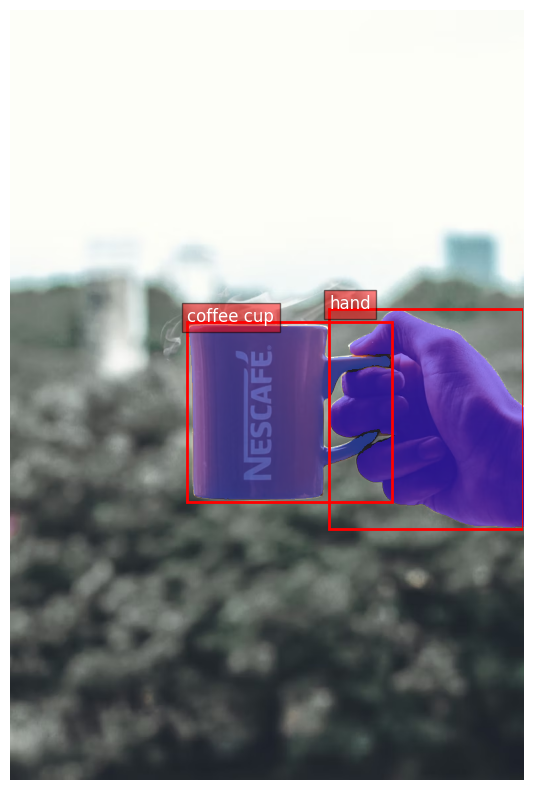

In [3]:
import os
import sys
sys.path.insert(0, '/content/Grounded-SAM-2/grounding_dino')
sys.path.append('/content/Grounded-SAM-2')

# Download checkpoints if they don't exist
if not os.path.exists("/content/Grounded-SAM-2/gdino_checkpoints/groundingdino_swint_ogc.pth"):
    !cd /content/Grounded-SAM-2/gdino_checkpoints && bash download_ckpts.sh
if not os.path.exists("/content/Grounded-SAM-2/checkpoints/sam2.1_hiera_large.pt"):
    !cd /content/Grounded-SAM-2/checkpoints && bash download_ckpts.sh

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.ops import box_convert
from grounding_dino.groundingdino.util.inference import load_image, predict, load_model
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

IMG_PATH = "/content/coffeecup.avif"
TEXT_PROMPT = "hand. coffee cup."
BOX_THRESHOLD = 0.25
TEXT_THRESHOLD = 0.25
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Model Configs
SAM2_CHECKPOINT = "/content/Grounded-SAM-2/checkpoints/sam2.1_hiera_large.pt"
SAM2_MODEL_CONFIG = "configs/sam2.1/sam2.1_hiera_l.yaml"
GROUNDING_DINO_CONFIG = "/content/Grounded-SAM-2/grounding_dino/groundingdino/config/GroundingDINO_SwinT_OGC.py"
GROUNDING_DINO_CHECKPOINT = "/content/Grounded-SAM-2/gdino_checkpoints/groundingdino_swint_ogc.pth"

# Load Models
grounding_model = load_model(GROUNDING_DINO_CONFIG, GROUNDING_DINO_CHECKPOINT, device=DEVICE)
sam2_model = build_sam2(SAM2_MODEL_CONFIG, SAM2_CHECKPOINT, device=DEVICE)
sam2_predictor = SAM2ImagePredictor(sam2_model)

# Load image
image_source, image = load_image(IMG_PATH)

# Predict bounding boxes with Grounding DINO
boxes, confidences, labels = predict(
    model=grounding_model,
    image=image,
    caption=TEXT_PROMPT,
    box_threshold=BOX_THRESHOLD,
    text_threshold=TEXT_THRESHOLD,
)

print(f"Detected {len(boxes)} objects: {labels}")

if len(boxes) > 0:
    # Convert boxes to xyxy format for SAM 2
    h, w, _ = image_source.shape
    boxes_xyxy = boxes * torch.Tensor([w, h, w, h])
    input_boxes = box_convert(boxes=boxes_xyxy, in_fmt="cxcywh", out_fmt="xyxy").numpy()

    # Predict masks with SAM 2
    sam2_predictor.set_image(image_source)

    masks, scores, logits = sam2_predictor.predict(
        point_coords=None,
        point_labels=None,
        box=input_boxes,
        multimask_output=False,
    )

    if masks.ndim == 4:
        masks = masks.squeeze(1)

    # Visualization
    plt.figure(figsize=(10, 10))
    plt.imshow(image_source)

    for i, (mask, box, label) in enumerate(zip(masks, input_boxes, labels)):
        # Overlay mask
        color = np.random.random(3)
        h_m, w_m = mask.shape[-2:]
        mask_image = mask.reshape(h_m, w_m, 1) * color.reshape(1, 1, -1)
        plt.gca().imshow(np.concatenate([mask_image, mask.reshape(h_m, w_m, 1) * 0.5], axis=-1))

        # Draw bounding box
        x0, y0, x1, y1 = box
        plt.gca().add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, edgecolor='red', facecolor='none', lw=2))
        plt.text(x0, y0, label, color='white', fontsize=12, bbox=dict(facecolor='red', alpha=0.5))

        # Save mask to disk
        safe_label = label.replace(' ', '_')
        mask_output_path = f"/content/mask_{safe_label}_{i}.png"
        cv2.imwrite(mask_output_path, (mask * 255).astype(np.uint8))
        print(f"Saved {label} mask to {mask_output_path}")

    plt.axis('off')
    plt.show()
else:
    print("No matching objects detected.")


In [6]:
import os
from google.colab import userdata
from huggingface_hub import login

# Create a Colab secret such as HF_TOKEN in the Secrets panel.
HF_TOKEN = userdata.get('HF_TOKEN')
if not HF_TOKEN:
    HF_TOKEN = os.environ.get('HF_TOKEN', '')

if HF_TOKEN:
    login(token=HF_TOKEN)
    print('Hugging Face login succeeded.')
else:
    print("Set a Colab secret named 'HF_TOKEN' or export HF_TOKEN before continuing.")


The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to /root/.cache/huggingface/token
Login successful
Hugging Face login succeeded.


In [9]:
import math
import numpy as np

def fit_lollipop_from_mask(mask: np.ndarray):
    points = np.argwhere(mask)
    h, w = mask.shape
    if len(points) < 10:
        raise ValueError("Mask too small to fit lollipop.")

    xy = points[:, ::-1].astype(np.float32)  # (x, y)
    center = xy.mean(axis=0)
    centered = xy - center

    cov = np.cov(centered.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    axis = eigvecs[:, np.argmax(eigvals)]  # main PCA axis

    proj = centered @ axis
    p0 = center + axis * proj.min()
    p1 = center + axis * proj.max()

    def border_distance(p):
        x, y = p
        return min(x, y, w - 1 - x, h - 1 - y)

    # Endpoint closer to image border is more likely to be wrist / forearm side
    if border_distance(p0) < border_distance(p1):
        p_wrist = p0
        p_tip = p1
    else:
        p_wrist = p1
        p_tip = p0

    # Palm center should be inside the image, not at the border side.
    # Put it a short distance from wrist toward the hand interior.
    c_palm = p_wrist + 0.30 * (p_tip - p_wrist)

    orth = np.array([-axis[1], axis[0]], dtype=np.float32)

    # Estimate palm width using points near palm center
    rel = xy - c_palm[None]
    along = rel @ axis
    across = rel @ orth
    keep = np.abs(along) < max(20.0, 0.12 * np.linalg.norm(p_tip - p_wrist))
    if keep.sum() < 10:
        keep = np.ones(len(xy), dtype=bool)

    palm_half_width = max(float(np.std(across[keep]) * 1.8), 8.0)

    theta = math.atan2(float(axis[1]), float(axis[0]))
    b1 = math.cos(theta)
    b2 = math.sin(theta)

    params = (float(c_palm[0]), float(c_palm[1]), float(palm_half_width), float(b1), float(b2))
    return params, p_wrist, p_tip


In [10]:
import cv2
import numpy as np

def intersect_ray_with_image_border(origin, direction, h, w):
    """
    origin: (x, y)
    direction: normalized 2D vector
    return: the intersection point of the ray with image border
    """
    x, y = origin
    dx, dy = direction

    ts = []

    eps = 1e-6
    if abs(dx) > eps:
        ts.append((0 - x) / dx)
        ts.append((w - 1 - x) / dx)
    if abs(dy) > eps:
        ts.append((0 - y) / dy)
        ts.append((h - 1 - y) / dy)

    ts = [t for t in ts if t > 0]
    if len(ts) == 0:
        return np.array([x, y], dtype=np.float32)

    t = min(ts)
    return np.array([x + t * dx, y + t * dy], dtype=np.float32)


def render_lollipop(mask_shape, params, p_wrist, p_tip=None, soft=False):
    h, w = mask_shape
    x, y, a, b1, b2 = params

    canvas = np.zeros((h, w), dtype=np.float32)

    # Palm circle
    palm_radius = int(round(1.25 * a))
    cv2.circle(canvas, (int(round(x)), int(round(y))), palm_radius, 1.0, -1)

    # Forearm strip direction: from palm center toward wrist side
    wrist_dir = np.array(p_wrist, dtype=np.float32) - np.array([x, y], dtype=np.float32)
    norm = np.linalg.norm(wrist_dir)
    if norm < 1e-6:
        wrist_dir = np.array([b1, b2], dtype=np.float32)
        norm = np.linalg.norm(wrist_dir)
    wrist_dir = wrist_dir / max(norm, 1e-6)

    # Extend strip toward image border
    p_start = np.array([x, y], dtype=np.float32)
    p_end = intersect_ray_with_image_border(p_start, wrist_dir, h, w)

    # Strip width uses a fixed ratio to palm size, closer to Affordance Diffusion
    strip_half_width = int(round(max(0.55 * a, 4)))

    # Build oriented rectangle
    orth = np.array([-wrist_dir[1], wrist_dir[0]], dtype=np.float32)
    p1 = p_start + orth * strip_half_width
    p2 = p_start - orth * strip_half_width
    p3 = p_end - orth * strip_half_width
    p4 = p_end + orth * strip_half_width

    poly = np.round(np.stack([p1, p2, p3, p4], axis=0)).astype(np.int32)
    cv2.fillConvexPoly(canvas, poly, 1.0)

    if soft:
        canvas = cv2.GaussianBlur(canvas, (0, 0), sigmaX=max(a * 0.35, 1.0), sigmaY=max(a * 0.35, 1.0))
        canvas = np.clip(canvas, 0.0, 1.0)
        return canvas

    return canvas > 0.5


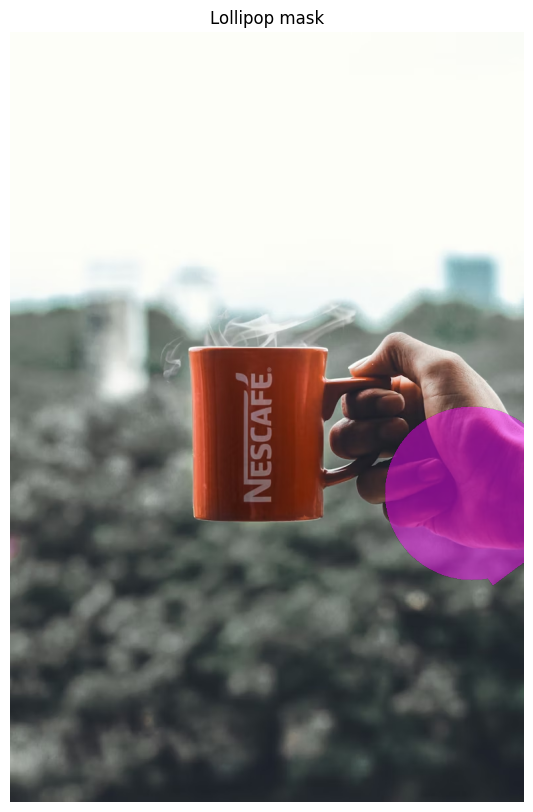

In [11]:
lolli_params, p_wrist, p_tip = fit_lollipop_from_mask(hand_mask)
lollipop_mask = render_lollipop(hand_mask.shape, lolli_params, p_wrist, p_tip, soft=False)

plt.figure(figsize=(8, 10))
plt.imshow(image_source)
plt.imshow(np.ma.masked_where(~lollipop_mask, lollipop_mask), alpha=0.45, cmap="spring")
plt.title("Lollipop mask")
plt.axis("off")
plt.show()

Lollipop params: (683.1491405111262, 679.5754649237523, 123.27730560302734, 0.5999949171792629, 0.8000038120903235)


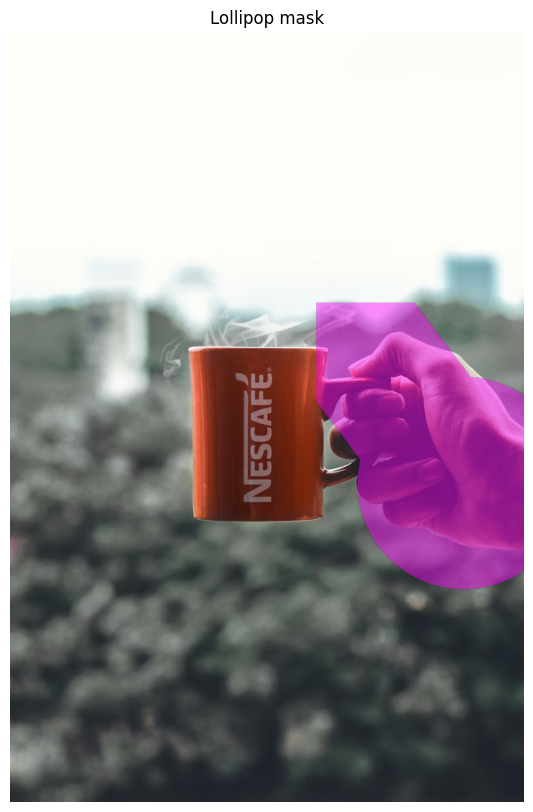

In [4]:
import math
import cv2
import numpy as np
import matplotlib.pyplot as plt

def fit_lollipop_from_mask(mask: np.ndarray):
    points = np.argwhere(mask)
    h, w = mask.shape
    if len(points) < 10:
        raise ValueError("Mask too small to fit lollipop.")

    xy = points[:, ::-1].astype(np.float32)  # (x, y)
    center = xy.mean(axis=0)
    centered = xy - center
    cov = np.cov(centered.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    axis = eigvecs[:, np.argmax(eigvals)]

    proj = centered @ axis
    p_min = center + axis * proj.min()
    p_max = center + axis * proj.max()

    # assume one end is wrist side, one end is fingertip side
    # for egocentric hand images, usually the farther-right / lower part is wrist side,
    # but here we just use min->wrist, max->tip as a generic approximation.
    p_wrist = p_min
    p_tip = p_max

    c_palm = p_wrist + 0.65 * (p_tip - p_wrist)

    orth = np.array([-axis[1], axis[0]], dtype=np.float32)
    transverse = centered @ orth
    a = max(float(np.std(transverse) * 2.0), 8.0)

    theta = math.atan2(float(axis[1]), float(axis[0]))
    b1 = math.cos(theta)
    b2 = math.sin(theta)

    params = (float(c_palm[0]), float(c_palm[1]), float(a), float(b1), float(b2))
    return params, p_wrist, p_tip

def render_lollipop(mask_shape, params, p_wrist, soft=False):
    h, w = mask_shape
    x, y, a, b1, b2 = params
    yy, xx = np.indices((h, w))

    if soft:
        sigma_circle = max(a, 1.0)
        circle = np.exp(-0.5 * (((xx - x) ** 2 + (yy - y) ** 2) / (sigma_circle ** 2)))
        out = circle.copy()
    else:
        out = np.zeros((h, w), dtype=np.float32)
        circle = (xx - x) ** 2 + (yy - y) ** 2 <= (1.3 * a) ** 2
        out[circle] = 1.0

    p0 = np.array(p_wrist, dtype=np.float32)
    p1 = np.array([x, y], dtype=np.float32)
    num = max(int(np.linalg.norm(p1 - p0)), 1)
    radius = max(int(round(0.6 * a)), 2)

    for t in np.linspace(0.0, 1.0, num):
        p = p0 * (1 - t) + p1 * t
        px, py = int(round(p[0])), int(round(p[1]))
        x0 = max(0, px - radius)
        x1 = min(w, px + radius + 1)
        y0 = max(0, py - radius)
        y1 = min(h, py + radius + 1)
        if soft:
            out[y0:y1, x0:x1] = np.maximum(out[y0:y1, x0:x1], 0.75)
        else:
            out[y0:y1, x0:x1] = 1.0

    if soft:
        return np.clip(out, 0.0, 1.0)
    return out > 0.5

# Extract the hand mask from the previous cell's output
if 'hand' in labels:
    hand_idx = labels.index('hand')
    hand_mask = masks[hand_idx]

    lolli_params, p_wrist, p_tip = fit_lollipop_from_mask(hand_mask)
    lollipop_mask = render_lollipop(hand_mask.shape, lolli_params, p_wrist, soft=False)

    print("Lollipop params:", lolli_params)

    plt.figure(figsize=(8, 10))
    plt.imshow(image_source)
    plt.imshow(np.ma.masked_where(~lollipop_mask, lollipop_mask), alpha=0.45, cmap="spring")
    plt.title("Lollipop mask")
    plt.axis("off")
    plt.show()
else:
    print("No hand mask found in the labels.")


## Step 3: mask 掉当前手后，inpaint 空白背景

这一阶段的目标是：

- 输入：原始图像 + lollipop mask
- 输出：去掉当前手之后的背景 / 物体修补结果

当前 notebook 中的设计假设：

- 先修补背景，再让生成模型去“加回”符合语义的人手
- 这可以把“背景恢复”和“语义抓取生成”拆成两个更稳定的问题

当前留白：

- 这里依然是对 `human hand` 做修补，不是最终 `prosthetic hand` 的真实场景。


In [7]:
# ==========================================
# 3. Inpainting 模型加载 (只需运行一次)
# ==========================================
from diffusers import AutoPipelineForInpainting
import torch

# Clear memory cache before loading the large inpainting model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

INPAINT_MODEL_ID = "diffusers/stable-diffusion-xl-1.0-inpainting-0.1"
DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if 'inpaint_pipe' not in globals():
    print("Loading Inpainting model into memory...")
    inpaint_pipe = AutoPipelineForInpainting.from_pretrained(
        INPAINT_MODEL_ID,
        torch_dtype=DTYPE,
        variant="fp16" if DEVICE == "cuda" else None,
    )
    inpaint_pipe = inpaint_pipe.to(DEVICE)
    inpaint_pipe.enable_attention_slicing()
    print("Inpainting model loaded successfully!")
else:
    print("Inpainting model already loaded in memory, skipping initialization.")

Inpainting model already loaded in memory, skipping initialization.


Running inpainting inference...


  0%|          | 0/29 [00:00<?, ?it/s]

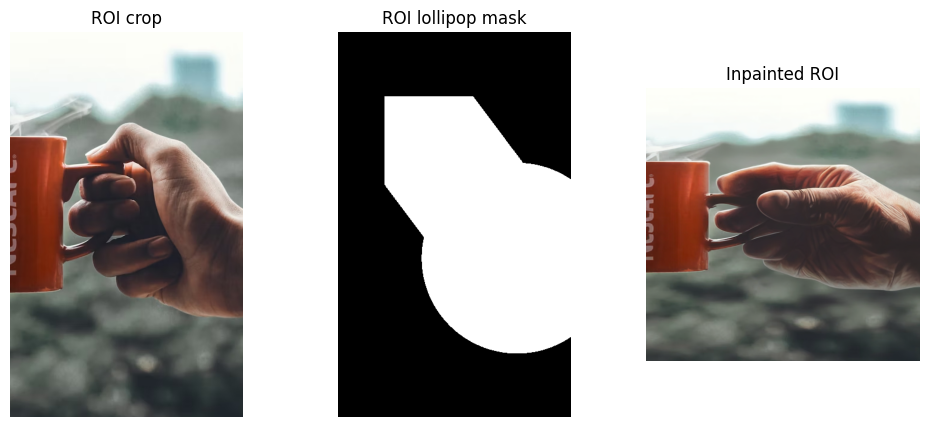

In [8]:
# ==========================================
# 4. Inpainting 推理 (修改提示词或更换图片后，只需运行此单元格)
# ==========================================
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def crop_from_mask(image, mask, pad_ratio=0.25):
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()

    h, w = image.shape[:2]
    bh = y1 - y0 + 1
    bw = x1 - x0 + 1

    pad_y = max(int(bh * pad_ratio), 16)
    pad_x = max(int(bw * pad_ratio), 16)

    x0 = max(0, x0 - pad_x)
    y0 = max(0, y0 - pad_y)
    x1 = min(w, x1 + pad_x)
    y1 = min(h, y1 + pad_y)
    return image[y0:y1, x0:x1], mask[y0:y1, x0:x1], (x0, y0, x1, y1)

def paste_crop_back(full_rgb, crop_rgb, crop_box):
    x0, y0, x1, y1 = crop_box
    out = full_rgb.copy()
    out[y0:y1, x0:x1] = crop_rgb
    return out

# Prepare data from previous steps
rgb_crop, lolli_crop_mask, crop_box = crop_from_mask(image_source, lollipop_mask)

# You can change the prompt here
inpaint_prompt = "background preserved, object preserved, realistic completion behind removed hand, no human hand visible"

crop_pil = Image.fromarray(rgb_crop)
mask_pil = Image.fromarray((lolli_crop_mask.astype(np.uint8) * 255))

print("Running inpainting inference...")
inpaint_result = inpaint_pipe(
    prompt=inpaint_prompt,
    image=crop_pil,
    mask_image=mask_pil,
    guidance_scale=8.0,
    strength=0.99,
    num_inference_steps=30,
).images[0]

inpaint_crop = np.array(inpaint_result)

# Visualization
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(rgb_crop)
plt.title("ROI crop")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(lolli_crop_mask, cmap="gray")
plt.title("ROI lollipop mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(inpaint_crop)
plt.title("Inpainted ROI")
plt.axis("off")
plt.show()

In [17]:
# ==========================================
# 补充：将掩码和图片保存到本地（重启前必须运行！）
# ==========================================
import numpy as np
from PIL import Image

# 将图片和提取好的掩码存入硬盘
Image.fromarray(image_source).save('/content/image_source_saved.png')
np.save('/content/lollipop_mask.npy', lollipop_mask)
print("✅ 数据已成功保存到硬盘！")
print("👉 接下来，请务必点击顶部菜单栏：'代码执行程序' (Runtime) -> '重新启动会话' (Restart Session)")
print("👉 重启后不要跑前面的单元格，直接滚动到下面的 '5. Flux-Fill 模型加载' 开始运行即可！")

✅ 数据已成功保存到硬盘！
👉 接下来，请务必点击顶部菜单栏：'代码执行程序' (Runtime) -> '重新启动会话' (Restart Session)
👉 重启后不要跑前面的单元格，直接滚动到下面的 '5. Flux-Fill 模型加载' 开始运行即可！


## Step 4: diffusion model 生成人手操作图像

这一阶段的目标是：

- 输入：原图中裁出的 ROI + lollipop mask + 语义任务提示词
- 输出：符合语义的人手操作图像

当前实现：

- 使用 `FLUX.1-Fill-dev`
- 在局部 ROI 上运行，而不是整图运行
- 该阶段默认假设 `Step 3` 已经输出了较干净的背景修补结果

注意：

- 后续如果切换到 API 版本 `FLUX Fill [pro]`，这一阶段的输入输出接口应保持不变。
- 这里输出的是“人手操作图像”，还不是最终假肢动作。


In [3]:
# Step 4 / 模型加载：用于根据语义提示在 lollipop ROI 内生成人手操作图像
# 本阶段忽略最终假肢控制，只关注生成的人手交互视觉先验。
# ==========================================
# 5. Flux-Fill 模型加载 (只需运行一次)
# ==========================================
# 升级依赖以支持 Flux Fill，最新版同时兼容 SDXL，且不影响后续的 HaMeR
!pip install -q -U diffusers transformers accelerate peft

import torch
from diffusers import FluxFillPipeline

# 清理显存
if torch.cuda.is_available():
    torch.cuda.empty_cache()

FLUX_FILL_MODEL_ID = "black-forest-labs/FLUX.1-Fill-dev"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if 'flux_fill_pipe' not in globals():
    print("Loading Flux-Fill model into memory...")
    flux_fill_pipe = FluxFillPipeline.from_pretrained(
        FLUX_FILL_MODEL_ID,
        torch_dtype=torch.bfloat16
    )
    flux_fill_pipe = flux_fill_pipe.to(DEVICE)
    print("Flux-Fill model loaded successfully!")
else:
    print("Flux-Fill model already loaded in memory, skipping initialization.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 16.3 MB/s eta 0:00:00


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading Flux-Fill model into memory...


Fetching 23 files:   0%|          | 0/23 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Flux-Fill model loaded successfully!


Running Flux-Fill inference...


  0%|          | 0/50 [00:00<?, ?it/s]

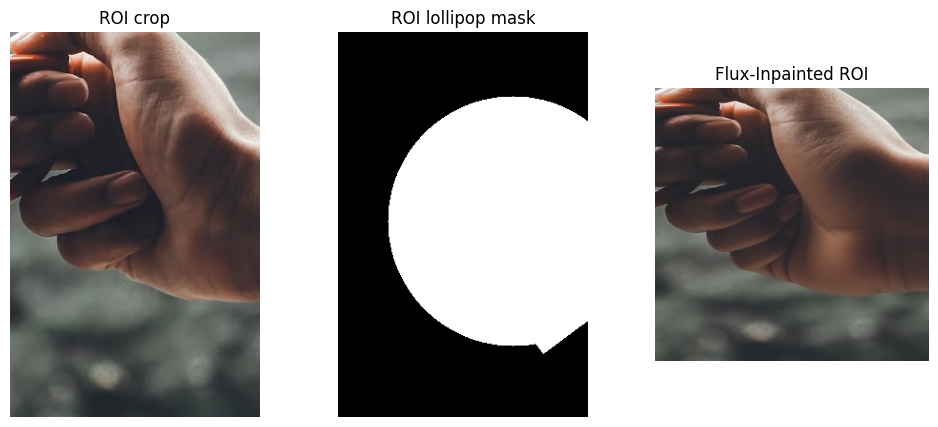

In [4]:
# Step 4 / 推理：输入修补后的 ROI、lollipop mask 和任务语义，输出人手操作图像
# TODO: 后续可替换为 API 版 FLUX Fill，但这里的输入输出协议应保持不变。
# ==========================================
# 6. Flux-Fill 推理 (修改提示词后，只需运行此单元格)
# ==========================================
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch

# 1. 加载重启前保存的数据
try:
    image_source = np.array(Image.open('/content/image_source_saved.png'))
    lollipop_mask = np.load('/content/lollipop_mask.npy')
except FileNotFoundError:
    print("❌ 找不到保存的数据！请确保你在重启前运行了上面那个保存数据的单元格。")
    raise

# 2. 裁剪 ROI (和之前 SDXL 相同的逻辑，能够提升生成质量)
def crop_from_mask(image, mask, pad_ratio=0.25):
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()

    h, w = image.shape[:2]
    bh, bw = y1 - y0 + 1, x1 - x0 + 1
    pad_y, pad_x = max(int(bh * pad_ratio), 16), max(int(bw * pad_ratio), 16)

    x0, y0 = max(0, x0 - pad_x), max(0, y0 - pad_y)
    x1, y1 = min(w, x1 + pad_x), min(h, y1 + pad_y)
    return image[y0:y1, x0:x1], mask[y0:y1, x0:x1], (x0, y0, x1, y1)

rgb_crop, lolli_crop_mask, crop_box = crop_from_mask(image_source, lollipop_mask)

crop_pil = Image.fromarray(rgb_crop)
mask_pil = Image.fromarray((lolli_crop_mask.astype(np.uint8) * 255))

# 3. Flux-Fill 提示词 (建议使用详细的自然语言描述)
flux_prompt = "A highly realistic background behind the object, no human hand, seamless continuation of the surface, extremely detailed, 8k"

print("Running Flux-Fill inference...")
flux_result = flux_fill_pipe(
    prompt=flux_prompt,
    image=crop_pil,
    mask_image=mask_pil,
    guidance_scale=30.0,  # Flux Fill 推荐较高的 guidance scale
    num_inference_steps=50,
).images[0]

flux_crop = np.array(flux_result)

# 4. 可视化对比
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(rgb_crop)
plt.title("ROI crop")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(lolli_crop_mask, cmap="gray")
plt.title("ROI lollipop mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(flux_crop)
plt.title("Flux-Inpainted ROI")
plt.axis("off")
plt.show()

## Step 5: 2D 人手图像恢复为 3D MANO 模型

这一阶段的目标是：

- 输入：`Step 4` 生成的人手操作图像
- 输出：MANO 参数、手部 mesh、关键点 / 指尖位置

当前实现：

- 使用 `HaMeR`
- 主要用于恢复 3D 手部结构和后续指尖位置分析

注意：

- 这一阶段完成后，才有条件进入 `Step 6` 的“人手到假肢动作映射”。
- 本 notebook 目前只做到 MANO 恢复，还没有把 MANO 映射为假肢命令。


In [5]:
%%capture
# Clone repo
!git clone --recursive https://github.com/geopavlakos/hamer.git
%cd hamer

In [6]:
# Step 5 / 环境安装：安装 HaMeR 及其依赖，用于从 2D 人手图像恢复 3D MANO
# Install dependencies
!pip install torch
!pip install -e .[all]
!pip install -v -e third-party/ViTPose

In [7]:
%%capture
# Get HaMeR model
!bash fetch_demo_data.sh
!wget https://github.com/JonathanLehner/Colab-collection/releases/download/MANO/mano_v1_2.zip
!unzip mano_v1_2.zip
!mv mano_v1_2/models/MANO_RIGHT.pkl _DATA/data/mano/
%rm -r mano_v1_2

In [8]:
# Step 5 / 推理：对输入图像运行 HaMeR，得到 mesh、MANO 参数和关键点
# TODO: 当前示例仍是官方 demo 路径，后续需要替换为 Step 4 生成结果目录。
# run hamer on a folder of images
!python demo.py \
--img_folder example_data --out_folder demo_out \
--batch_size=48 --side_view --save_mesh

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
apex is not installed
apex is not installed
apex is not installed
/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:27: UserWarning: Fail to import ``MultiScaleDeformableAttention`` from ``mmcv.ops.multi_scale_deform_attn``, You should install ``mmcv-full`` if you need this module. 
  warnings.warn('Fail to import ``MultiScaleDeformableAttention`` from '
  [============================================================] 100.0% of 5757.9MB file  
Extracting file: hamer_demo_data.tar.gz
_DATA/
_DATA/vitpose_ckpts/
_DATA/vitpose_ckpts/vitpose+_huge/
_DATA/vitpose_ckpts/vitpose+_huge/wholebody.pth
_DATA/data/
_DATA/data/mano_mean_params.npz
_DATA/data/mano/
_DATA/hamer_ckpts/
_DATA/hamer_ckpts/model_c

In [ ]:
from IPython.display import Image, display
import os
# https://colab.research.google.com/drive/1Ex4gE5v1bPR3evfhtG7sDHxQGsWwNwby?usp=sharing
output_images = ["demo_out/" + i for i in os.listdir("demo_out/") if ".jpg" in i]
for img in output_images:
  display(Image(img))

## Step 6: 提取指尖位置并转换为假肢动作（尚未实现）

计划中的输入：

- `HaMeR` 输出的 MANO 参数
- 手部关键点，尤其是各指尖位置
- 可选手掌法向、抓取方向、接触拓扑

计划中的输出：

- 假肢低维动作命令，例如：
  - `grasp_type`
  - `thumb_mode`
  - `wrist_rotation`
  - `aperture`
  - `force_level`

当前留白：

- 还没有把 MANO / mesh 自动转换为假肢控制参数
- 还没有接入规则型或优化型 retargeting
- 还没有接入真实假肢执行器

后续建议：

1. 先从 `HaMeR` 结果中稳定提取指尖 3D 坐标
2. 定义 `human prior -> prosthetic action` 的规则映射
3. 再把该映射封装成独立模块，在本地 conda 环境中运行
